# Resultado calificación total del modelo CAMEL

Para obtener la calificación total (usando todos los indicadores previamente calculados) se tienen los siguientes pasos:

1. Descarga y lectura de los datos (Resultado de calificación individual de los indicadores).
2. Extracción y valoración del PCA.
3. Creación de los rangos (percentiles para las variables).
4. Calificación modelo CAMEL - general.
5. Calificación modelo CAMEL - sectorizado

# 1. Extracción de datos

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

In [22]:
datos=pd.read_csv("../../BD/Registros_CAMEL_sin_solvencia_categorizados.csv")
datos.head()

,ID_registro,ano,mes,ID_indicador,ID_cooperativa,valor,categoria
0,1,2021,1,Quebranto Patrimonial,CAJA COOPERATIVA CREDICOOP,1.408555,Medianas
1,3,2021,1,Relación entre Aportes sociales mínimos no red...,CAJA COOPERATIVA CREDICOOP,0.895748,Medianas
2,4,2021,1,Relación entre el Capital Institucional y el A...,CAJA COOPERATIVA CREDICOOP,0.088234,Medianas
3,5,2021,2,Quebranto Patrimonial,CAJA COOPERATIVA CREDICOOP,1.410959,Medianas
4,7,2021,2,Relación entre Aportes sociales mínimos no red...,CAJA COOPERATIVA CREDICOOP,0.895640,Medianas


In [23]:
# en la columna "valor" cambiar nulos por o
datos["valor"] = datos["valor"].fillna(0)
#cuando el valor de la columna "valor" sea ' ', cambiarlo por 0
datos["valor"] = datos["valor"].replace(' ', 0)
#cambiar el tipo de dato de la columna "valor" a float
datos["valor"] = datos["valor"].astype(float)

In [24]:
len(datos["ID_indicador"].unique())

16

# 2. Cálculo PCA

In [25]:
def pesos_pca_grupo_coops(
    df,
    lista_coops,
    col_nombre="ID_cooperativa",
    n_componentes=3
):
    
    # filtrar cooperativas
    df_filtrado = df[df[col_nombre].isin(lista_coops)].copy()
    
    if df_filtrado.empty:
        raise ValueError("No hay datos para las cooperativas indicadas")
    
    # LIMPIEZA 
    df_filtrado["valor"] = (
        df_filtrado["valor"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    
    df_filtrado["valor"] = pd.to_numeric(df_filtrado["valor"], errors="coerce")
    
    # pivot (matriz indicadores)
    df_pivot = df_filtrado.pivot_table(
        index=col_nombre,
        columns="ID_indicador",
        values="valor",
        aggfunc="mean"
    )
    
    # imputar faltantes
    imputer = SimpleImputer(strategy="mean")
    X_imputed = imputer.fit_transform(df_pivot)
    
    # escalar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    
    # PCA
    pca = PCA(n_components=min(n_componentes, df_pivot.shape[1]))
    pca.fit(X_scaled)
    
    loadings = pd.DataFrame(
        pca.components_.T,
        index=df_pivot.columns
    )
    
    pesos = (loadings**2).mean(axis=1)
    
    # porcentaje
    pesos = (pesos / pesos.sum()) 
    
    return pesos.sort_values(ascending=False)

# 3. Cálculo Rangos

In [26]:
INDICADORES_INVERSOS = [
    "Indicador de calidad por riesgo",
    "Indicador de calidad por riesgo con castigos",
    "Indicador de Cobertura de la Cartera Total en Riesgo",
    "Indicador de relación entre las obligaciones financieras y el pasivo total",
    "Indicador de Margen Financiero de Operación",
    "Indicador de Margen Operacional"
]

INDICADOR_SOLVENCIA = "Relación Solvencia"
INDICADOR_IRL = "IRL"

PERCENTILES = [10,20,30,40,50,60,70,80,90]


# ======================================================
# CALCULAR PERCENTILES
# ======================================================

def calcular_percentiles(df, indicadores):

    resultados = {}

    for indicador in indicadores:

        subset = df[df["ID_indicador"] == indicador].copy()

        if subset.empty:
            continue

        valores = subset["valor"].dropna()

        # ----------------------------------
        # IRL → aplicar log10(x)
        # ----------------------------------
        if indicador== INDICADOR_IRL:

            valores = valores[valores > 0]

            if len(valores) == 0:
                continue

            valores = np.log10(valores)

        # ----------------------------------
        # Detectar muchos ceros
        # ----------------------------------
        porcentaje_ceros = (valores == 0).mean()

        if porcentaje_ceros >= 0.10:

            valores_sin_cero = valores[valores > 0]

            p = {}

            # P10 = 0
            p[10] = 0

            if len(valores_sin_cero) > 0:

                for q in [20,30,40,50,60,70,80,90]:

                    q_ajustado = (q - 10) / 90

                    p[q] = valores_sin_cero.quantile(q_ajustado)

            else:

                for q in [20,30,40,50,60,70,80,90]:
                    p[q] = 0

        else:

            p = {
                q: valores.quantile(q / 100)
                for q in PERCENTILES
            }

        # ----------------------------------
        # Relación solvencia → P10 = 9
        # ----------------------------------
        if indicador == INDICADOR_SOLVENCIA:

            p[10] = 9

            for q in [20,30,40,50,60,70,80,90]:

                p[q] = max(
                    p[q],
                    p[10]
                )

        resultados[indicador] = p

    return resultados


# ======================================================
# ASIGNAR CALIFICACIÓN
# ======================================================

def asignar_calificacion(valor, cortes, inverso=False):

    limites = sorted(cortes.items())

    if not inverso:

        for i, (_, limite) in enumerate(limites):

            if valor <= limite:
                return i + 1

        return 10

    else:

        limites_valores = [x[1] for x in limites]

        for i, limite in enumerate(reversed(limites_valores)):

            if valor >= limite:
                return i + 1

        return 10


# ======================================================
# CALIFICAR DATAFRAME
# ======================================================

def calificar_dataframe(df):

    df = df.copy()

    indicadores = df["ID_indicador"].unique()

    percentiles = calcular_percentiles(
        df,
        indicadores
    )

    calificaciones = []

    for _, row in df.iterrows():

        indicador = row["ID_indicador"]

        valor = row["valor"]

        if pd.isna(valor):
            calificaciones.append(None)
            continue

        # -------------------------
        # IRL → aplicar log10
        # -------------------------
        if indicador == INDICADOR_IRL:

            if valor <= 0:
                calificaciones.append(None)
                continue

            valor = np.log10(valor)

        inverso = indicador in INDICADORES_INVERSOS

        nota = asignar_calificacion(
            valor=valor,
            cortes=percentiles[indicador],
            inverso=inverso
        )

        calificaciones.append(nota)

    df["calificacion"] = calificaciones

    return df, percentiles

In [27]:
def calcular_calificaciones_formato_lista(df: pd.DataFrame):

    if df.empty:
        return []

    columnas_necesarias = {
        'ID_indicador',
        'ID_cooperativa',
        'valor'
    }

    if not columnas_necesarias.issubset(df.columns):
        raise ValueError("Faltan columnas necesarias")

    df = df.copy()

    # ---------------------------------
    # Calcular percentiles (tu lógica)
    # ---------------------------------
    indicadores = df["ID_indicador"].unique()

    percentiles = calcular_percentiles(
        df,
        indicadores
    )

    resultados_temp = []

    # ---------------------------------
    # Calificar fila por fila
    # ---------------------------------
    for _, row in df.iterrows():

        indicador = row["ID_indicador"]
        cooperativa = row["ID_cooperativa"]
        valor = row["valor"]

        if pd.isna(valor):
            continue

        # IRL → log10
        if indicador == INDICADOR_IRL:

            if valor <= 0:
                continue

            valor = np.log10(valor)

        inverso = indicador in INDICADORES_INVERSOS

        calificacion = asignar_calificacion(
            valor=valor,
            cortes=percentiles[indicador],
            inverso=inverso
        )

        resultados_temp.append({
            "ID_cooperativa": str(cooperativa),
            "ID_indicador": str(indicador),
            "calificacion": int(calificacion)
        })

    # ---------------------------------
    # Promediar si una cooperativa
    # tiene varias filas del mismo indicador
    # ---------------------------------
    df_result = pd.DataFrame(resultados_temp)

    if df_result.empty:
        return []

    df_result = (
        df_result
        .groupby(
            ["ID_cooperativa", "ID_indicador"],
            as_index=False
        )["calificacion"]
        .mean()
        .round()
        .astype({
            "calificacion": int
        })
    )

    # ---------------------------------
    # Construir formato final
    # ---------------------------------
    resultado_final = {}

    for _, row in df_result.iterrows():

        coop = row["ID_cooperativa"]
        indicador = row["ID_indicador"]
        calificacion = row["calificacion"]

        if coop not in resultado_final:

            resultado_final[coop] = {
                "ID_cooperativa": coop,
                "calificaciones": {}
            }

        resultado_final[coop]["calificaciones"][
            indicador
        ] = calificacion

    return list(resultado_final.values())

In [28]:
calificaciones=calcular_calificaciones_formato_lista(datos)

In [29]:
df,percentiles=calificar_dataframe(datos)

In [30]:
percentiles_df = pd.DataFrame(percentiles).T
percentiles_df

,10,20,30,40,50,60,70,80,90
Quebranto Patrimonial,1.179999,1.247984,1.297031,1.345712,1.408241,1.531161,1.673152,1.810446,2.125311
Relación entre Aportes sociales mínimos no reducibles y Capital Social,0.327353,0.442782,0.531016,0.593729,0.649385,0.704056,0.759461,0.830934,0.917754
Relación entre el Capital Institucional y el Activo Total,0.033141,0.052000,0.063659,0.072434,0.080481,0.092157,0.104706,0.124912,0.163269
Indicador de Cobertura de la Cartera Total en Riesgo,0.024582,0.030475,0.036747,0.043077,0.050712,0.058982,0.069277,0.081716,0.103545
Indicador de calidad por riesgo,0.029691,0.041042,0.049685,0.057468,0.066312,0.077155,0.088240,0.102990,0.131186
Indicador de calidad por riesgo con castigos,0.002059,0.005620,0.009770,0.017193,0.023641,0.034340,0.044773,0.059586,0.088994
Activo Productivo,0.738115,0.784929,0.815676,0.841122,0.861424,0.878851,0.895976,0.915684,0.939622
Indicador de Cobertura individual de la cartera improductiva para la cartera en Riesgo,0.000000,0.303694,0.403853,0.477985,0.540574,0.591281,0.650539,0.719742,0.807202
Estructura de Balance,1.089767,1.191375,1.280715,1.352071,1.441414,1.590279,1.832412,2.239169,2.902202
Indicador de Margen Financiero de Operación,0.519952,0.597811,0.652501,0.696553,0.737398,0.776951,0.809351,0.845868,0.887694


# 4. Cálculo modelo CAMEL - general

In [31]:
lista_coops = datos["ID_cooperativa"].unique().tolist()
pca=pesos_pca_grupo_coops(
    datos,
    lista_coops=lista_coops,
    col_nombre="ID_cooperativa",
    n_componentes=3
)

In [32]:
pca_porcentaje=pca*100
pca_porcentaje

ID_indicador
Indicador de rentabilidad sobre recursos propios - ROE                                    11.748243
Estructura de Balance                                                                     10.423473
Indicador de Margen Financiero de Operación                                               10.107286
Quebranto Patrimonial                                                                      8.521462
Indicador de Cobertura de la Cartera Total en Riesgo                                       7.860643
Indicador de rentabilidad sobre el capital invertido - ROIC                                7.297656
Relación entre el Capital Institucional y el Activo Total                                  6.994138
Indicador de calidad por riesgo                                                            6.862230
Indicador de margen neto                                                                   6.750913
Indicador de Margen Operacional                                                        

In [17]:
pca

ID_indicador
Indicador de rentabilidad sobre recursos propios - ROE                                    0.117482
Estructura de Balance                                                                     0.104235
Indicador de Margen Financiero de Operación                                               0.101073
Quebranto Patrimonial                                                                     0.085215
Indicador de Cobertura de la Cartera Total en Riesgo                                      0.078606
Indicador de rentabilidad sobre el capital invertido - ROIC                               0.072977
Relación entre el Capital Institucional y el Activo Total                                 0.069941
Indicador de calidad por riesgo                                                           0.068622
Indicador de margen neto                                                                  0.067509
Indicador de Margen Operacional                                                           0.0589

In [18]:
def calcular_camel(lista, pesos):
    # Normalizar pesos
    pesos_norm = pesos / pesos.sum()

    resultados = []

    for coop in lista:
        nombre = coop["ID_cooperativa"]
        califs = coop["calificaciones"]

        score = 0

        for indicador, peso in pesos_norm.items():
            calificacion = califs.get(indicador, 0)  # si falta, toma 0
            score += calificacion * peso

        resultados.append({
            "ID_cooperativa": nombre,
            "CAMEL_score": score
        })

    return pd.DataFrame(resultados)

In [19]:
# Calcular CAMEL para todas las cooperativas
camel_definitivo = calcular_camel(calificaciones, pca)
camel_definitivo

,ID_cooperativa,CAMEL_score
0,CAJA COOPERATIVA CREDICOOP,4.491826
1,CAJA COOPERATIVA PETROLERA,4.664210
2,CASA NACIONAL DEL PROFESOR,5.364029
3,CESCA COOPERATIVA DE AHORRO Y CREDITO,4.806001
4,COOCERVUNION COOPERATIVA DE AHORRO Y CREDITO,4.505428
...,...,...
133,FORJAR COOPERATIVA DE AHORRO Y CREDITO,6.441391
134,GRAN COOPERATIVA DE ENERGIA ELECTRICA Y RECURS...,6.732839
135,LA COOPERATIVA DE AHORRO Y CREDITO SUCREDITO,5.911646
136,MICROEMPRESAS DE COLOMBIA COOPERATIVA DE AHORR...,5.969719


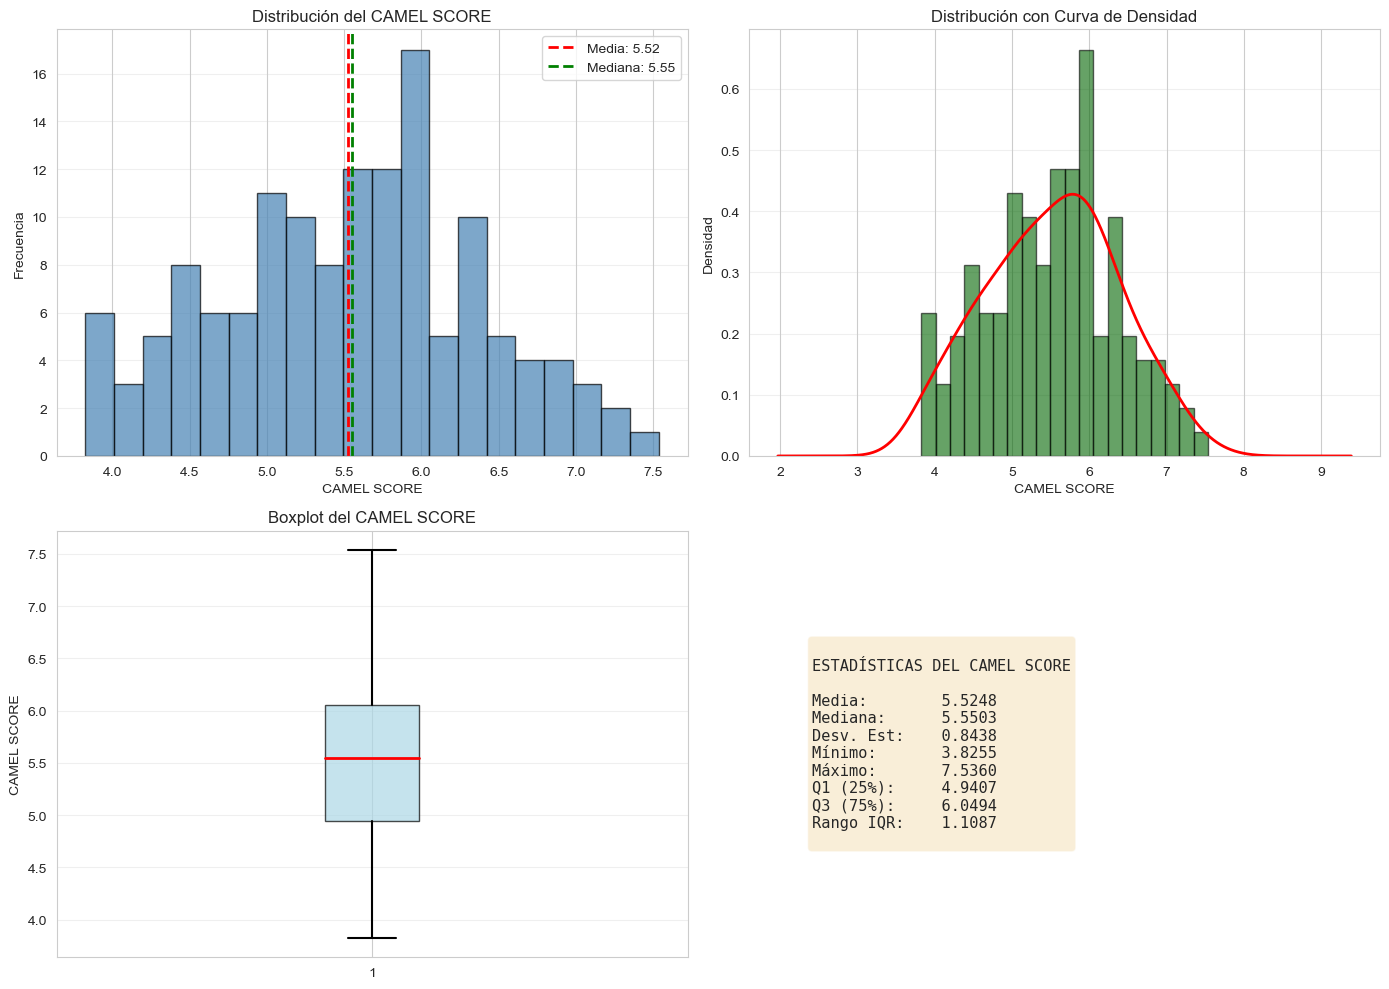

In [20]:
camel_ultimo=camel_definitivo.copy()
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")

# Crear figura con múltiples visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histograma simple
axes[0, 0].hist(camel_ultimo['CAMEL_score'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 0].axvline(camel_ultimo['CAMEL_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {camel_ultimo["CAMEL_score"].mean():.2f}')
axes[0, 0].axvline(camel_ultimo['CAMEL_score'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {camel_ultimo["CAMEL_score"].median():.2f}')
axes[0, 0].set_xlabel('CAMEL SCORE')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución del CAMEL SCORE')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histograma con KDE
axes[0, 1].hist(camel_ultimo['CAMEL_score'], bins=20, edgecolor='black', color='darkgreen', alpha=0.6, density=True)
camel_ultimo['CAMEL_score'].plot(kind='kde', ax=axes[0, 1], color='red', linewidth=2)
axes[0, 1].set_xlabel('CAMEL SCORE')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].set_title('Distribución con Curva de Densidad')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Boxplot
axes[1, 0].boxplot(camel_ultimo['CAMEL_score'], vert=True, patch_artist=True, 
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5))
axes[1, 0].set_ylabel('CAMEL SCORE')
axes[1, 0].set_title('Boxplot del CAMEL SCORE')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Estadísticas resumidas
stats_text = f"""
ESTADÍSTICAS DEL CAMEL SCORE

Media:        {camel_ultimo['CAMEL_score'].mean():.4f}
Mediana:      {camel_ultimo['CAMEL_score'].median():.4f}
Desv. Est:    {camel_ultimo['CAMEL_score'].std():.4f}
Mínimo:       {camel_ultimo['CAMEL_score'].min():.4f}
Máximo:       {camel_ultimo['CAMEL_score'].max():.4f}
Q1 (25%):     {camel_ultimo['CAMEL_score'].quantile(0.25):.4f}
Q3 (75%):     {camel_ultimo['CAMEL_score'].quantile(0.75):.4f}
Rango IQR:    {camel_ultimo['CAMEL_score'].quantile(0.75) - camel_ultimo['CAMEL_score'].quantile(0.25):.4f}
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center', 
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()



# 5. Cálculo modelo CAMEL - sectorizado

Además, generar gráficos estadísticos para los resultados tanto categorizados como generales, que sirvan para complementar el análisis de los resultados.

In [20]:
datos["categoria"].unique()

array(['Micro 1', 'Medianas', 'Megas', 'Pequeñas', 'Grandes', 'Micro 2',
       'Top 4'], dtype=object)

In [22]:
import pandas as pd

# ============================================
# CATEGORÍAS
# ============================================

categorias = [
    "Megas",
    "Grandes",
    "Medianas",
    "Pequeñas",
    "Micro 1",
    "Micro 2"
]

# ============================================
# ARCHIVO EXCEL
# ============================================

nombre_excel = "../../tablas/percentiles_y_rangos/percentiles_indicadores_categorizados.xlsx"

with pd.ExcelWriter(nombre_excel, engine="openpyxl") as writer:

    for categoria in categorias:

        # Filtrar datos
        datos_categoria = datos.loc[
            datos["categoria"] == categoria
        ]

        # Calcular percentiles
        df, percentiles = calificar_dataframe(
            datos_categoria
        )

        # Convertir a DataFrame
        percentiles_df = pd.DataFrame(
            percentiles
        ).T

        # Guardar en hoja con nombre de categoría
        percentiles_df.to_excel(
            writer,
            sheet_name=categoria[:31],  # límite Excel
            index=True
        )

print("Archivo Excel generado correctamente.")


Archivo Excel generado correctamente.


In [23]:
import pandas as pd

# ============================================
# CATEGORÍAS
# ============================================

categorias = [
    "Megas",
    "Grandes",
    "Medianas",
    "Pequeñas",
    "Micro 1",
    "Micro 2"
]

# ============================================
# ARCHIVO EXCEL
# ============================================

nombre_excel = "../../tablas/percentiles_y_rangos/PCA_indicadores_categorizados.xlsx"

with pd.ExcelWriter(nombre_excel, engine="openpyxl") as writer:

    for categoria in categorias:

        # ============================================
        # FILTRAR DATOS
        # ============================================

        datos_categoria = datos.loc[
            datos["categoria"] == categoria
        ]

        # ============================================
        # LISTA DE COOPERATIVAS
        # ============================================

        lista_coops = datos_categoria[
            "ID_cooperativa"
        ].unique().tolist()

        # ============================================
        # CALCULAR PCA
        # ============================================

        pca = pesos_pca_grupo_coops(
            datos_categoria,
            lista_coops=lista_coops,
            col_nombre="ID_cooperativa",
            n_componentes=3
        )

        # ============================================
        # PASAR A PORCENTAJE
        # ============================================

        pca_porcentaje = pca * 100

        # ============================================
        # CONVERTIR A DATAFRAME
        # ============================================

        if isinstance(pca_porcentaje, pd.Series):
            pca_df = pca_porcentaje.to_frame(
                name="peso_porcentaje"
            )
        else:
            pca_df = pd.DataFrame(pca_porcentaje)

        # ============================================
        # GUARDAR EN EXCEL
        # ============================================

        pca_df.to_excel(
            writer,
            sheet_name=categoria[:31],
            index=True
        )

print("Archivo Excel generado correctamente.")


Archivo Excel generado correctamente.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

# ============================================
# ARCHIVO DE SALIDA
# ============================================

nombre_excel = "../../tablas/camel/resultado_CAMEL/resultado_camel_categorizado.xlsx"

# Crear writer
with pd.ExcelWriter(nombre_excel, engine="openpyxl") as writer:

    coperativas = ['Micro 1', 'Medianas', 'Megas',
                   'Pequeñas', 'Grandes', 'Micro 2']

    for coperativa in coperativas:

        # ============================================
        # FILTRAR DATOS
        # ============================================

        datos_categoria = datos.loc[
            datos["categoria"] == coperativa
        ]

        lista_coops = datos_categoria[
            "ID_cooperativa"
        ].unique().tolist()

        # ============================================
        # CALCULAR PCA Y CAMEL
        # ============================================

        pca_ = pesos_pca_grupo_coops(
            datos_categoria,
            lista_coops=lista_coops,
            col_nombre="ID_cooperativa",
            n_componentes=3
        )

        calificaciones_ = calcular_calificaciones_formato_lista(
            datos_categoria
        )

        camel_definitivo = calcular_camel(
            calificaciones_,
            pca_
        )

        camel_ultimo = camel_definitivo.copy()

        # ============================================
        # GUARDAR TABLA EN EXCEL
        # ============================================

        nombre_hoja = coperativa[:31]  # Excel limita nombres

        camel_ultimo.to_excel(
            writer,
            sheet_name=nombre_hoja,
            index=False
        )

        # ============================================
        # CREAR GRAFICAS
        # ============================================

        sns.set_style("whitegrid")

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Histograma
        axes[0, 0].hist(
            camel_ultimo['CAMEL_score'],
            bins=20,
            edgecolor='black',
            color='steelblue',
            alpha=0.7
        )

        axes[0, 0].axvline(
            camel_ultimo['CAMEL_score'].mean(),
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Media: {camel_ultimo["CAMEL_score"].mean():.2f}'
        )

        axes[0, 0].axvline(
            camel_ultimo['CAMEL_score'].median(),
            color='green',
            linestyle='--',
            linewidth=2,
            label=f'Mediana: {camel_ultimo["CAMEL_score"].median():.2f}'
        )

        axes[0, 0].set_title('Distribución CAMEL')
        axes[0, 0].legend()

        # KDE
        axes[0, 1].hist(
            camel_ultimo['CAMEL_score'],
            bins=20,
            density=True,
            alpha=0.6
        )

        camel_ultimo['CAMEL_score'].plot(
            kind='kde',
            ax=axes[0, 1]
        )

        axes[0, 1].set_title('Densidad')

        # Boxplot
        axes[1, 0].boxplot(
            camel_ultimo['CAMEL_score'],
            vert=True,
            patch_artist=True
        )

        axes[1, 0].set_title('Boxplot')

        # Estadísticas
        stats_text = f"""
Media:      {camel_ultimo['CAMEL_score'].mean():.4f}
Mediana:    {camel_ultimo['CAMEL_score'].median():.4f}
Std:        {camel_ultimo['CAMEL_score'].std():.4f}
Min:        {camel_ultimo['CAMEL_score'].min():.4f}
Max:        {camel_ultimo['CAMEL_score'].max():.4f}
"""

        axes[1, 1].text(
            0.1,
            0.5,
            stats_text,
            fontsize=11
        )

        axes[1, 1].axis('off')

        plt.tight_layout()

        # ============================================
        # GUARDAR IMAGEN TEMPORAL
        # ============================================
        nombre_imagen = f"../../tablas/camel/resultado_CAMEL/estadísticas/{coperativa}_estadisticas.png"

        plt.savefig(nombre_imagen, dpi=300)
        plt.close()

# ============================================
# INSERTAR IMAGENES EN EXCEL
# ============================================

wb = load_workbook(nombre_excel)

for coperativa in coperativas:

    nombre_hoja = coperativa[:31]

    ws = wb[nombre_hoja]

    img = Image(f"../../tablas/camel/resultado_CAMEL/estadísticas/{coperativa}_estadisticas.png")

    # Posición donde aparecerá la imagen
    ws.add_image(img, "H2")

# Guardar cambios finales
wb.save(nombre_excel)

print("Excel generado correctamente.")

Excel generado correctamente.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

# ============================================
# CALCULAR CAMEL GENERAL (SIN SEGMENTACIÓN)
# ============================================

lista_coops = datos["ID_cooperativa"].unique().tolist()

pca_ = pesos_pca_grupo_coops(
    datos,
    lista_coops=lista_coops,
    col_nombre="ID_cooperativa",
    n_componentes=3
)

calificaciones_ = calcular_calificaciones_formato_lista(
    datos
)

camel_definitivo = calcular_camel(
    calificaciones_,
    pca_
)

camel_ultimo = camel_definitivo.copy()

# ============================================
# NOMBRE ARCHIVO
# ============================================

nombre_excel = "../../tablas/camel/resultado_CAMEL/resultado_camel_general.xlsx"

# ============================================
# GUARDAR DATAFRAME EN EXCEL
# ============================================

with pd.ExcelWriter(nombre_excel, engine="openpyxl") as writer:

    camel_ultimo.to_excel(
        writer,
        sheet_name="CAMEL_GENERAL",
        index=False
    )

# ============================================
# CREAR GRÁFICAS
# ============================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histograma
axes[0, 0].hist(
    camel_ultimo['CAMEL_score'],
    bins=20,
    edgecolor='black',
    color='steelblue',
    alpha=0.7
)

axes[0, 0].axvline(
    camel_ultimo['CAMEL_score'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Media: {camel_ultimo["CAMEL_score"].mean():.2f}'
)

axes[0, 0].axvline(
    camel_ultimo['CAMEL_score'].median(),
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Mediana: {camel_ultimo["CAMEL_score"].median():.2f}'
)

axes[0, 0].set_xlabel('CAMEL SCORE')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución del CAMEL SCORE')
axes[0, 0].legend()

# 2. Histograma con KDE
axes[0, 1].hist(
    camel_ultimo['CAMEL_score'],
    bins=20,
    density=True,
    edgecolor='black',
    alpha=0.6
)

camel_ultimo['CAMEL_score'].plot(
    kind='kde',
    ax=axes[0, 1],
    linewidth=2
)

axes[0, 1].set_title('Distribución con KDE')

# 3. Boxplot
axes[1, 0].boxplot(
    camel_ultimo['CAMEL_score'],
    vert=True,
    patch_artist=True
)

axes[1, 0].set_title('Boxplot CAMEL')

# 4. Estadísticas
stats_text = f"""
ESTADÍSTICAS

Media:      {camel_ultimo['CAMEL_score'].mean():.4f}
Mediana:    {camel_ultimo['CAMEL_score'].median():.4f}
Std:        {camel_ultimo['CAMEL_score'].std():.4f}
Min:        {camel_ultimo['CAMEL_score'].min():.4f}
Max:        {camel_ultimo['CAMEL_score'].max():.4f}

Q1:         {camel_ultimo['CAMEL_score'].quantile(0.25):.4f}
Q3:         {camel_ultimo['CAMEL_score'].quantile(0.75):.4f}
"""

axes[1, 1].text(
    0.1,
    0.5,
    stats_text,
    fontsize=11,
    family='monospace'
)

axes[1, 1].axis('off')

plt.tight_layout()

# ============================================
# GUARDAR IMAGEN
# ============================================

nombre_imagen = "../../tablas/camel/resultado_CAMEL/estadísticas/camel_general.png"

plt.savefig(nombre_imagen, dpi=300)
plt.close()

# ============================================
# INSERTAR IMAGEN EN EXCEL
# ============================================

wb = load_workbook(nombre_excel)

ws = wb["CAMEL_GENERAL"]

img = Image(nombre_imagen)

# Ajustar tamaño opcional
img.width = 900
img.height = 600

# Posición en la hoja
ws.add_image(img, "H2")

# Guardar
wb.save(nombre_excel)

print("Excel generado correctamente.")

Excel generado correctamente.
